# Lab Instructions

You have been hired by a record executive to design a guaranteed smash hit song based on data.  The exec has decided that if you make a song that has all the most popular features of recent songs then it will definitely be a hit.  So if - for example - the most common key in the Spotify data is C# then we would want the song we are designing to also be in C#.  If a "typical" value of BPM is between 120 and 130 then we would want the song we are designing to also have a tempo between 120 and 130 BMP.

Visualize and describe the distribution of:
* BPM
* Key
* Mode
* Danceability
* Energy
* Speechiness
* Acousticness

Based on your visualizations and calculations, what values for each of these features would make a song a guaranteed smash hit?  For quantitative features, you should propose a range of values.

Use a large language model to help you write code to identify if there are any songs in the Spotify dataset that meet all of the criteria we determined.  What is/are the artist(s) and title(s) of the song?  Were any of these songs actually popular?

Pick a song that you know was a smash hit. How do the values of BPM, key, mode, danceability, etc. compare to other songs? 

**Hint:**  Import the Spotify data using `df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')`.

In [1]:
import pandas as pd

df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


In [2]:
df.columns.tolist()

['track_name',
 'artist(s)_name',
 'artist_count',
 'released_year',
 'released_month',
 'released_day',
 'in_spotify_playlists',
 'in_spotify_charts',
 'streams',
 'in_apple_playlists',
 'in_apple_charts',
 'in_deezer_playlists',
 'in_deezer_charts',
 'in_shazam_charts',
 'bpm',
 'key',
 'mode',
 'danceability_%',
 'valence_%',
 'energy_%',
 'acousticness_%',
 'instrumentalness_%',
 'liveness_%',
 'speechiness_%']

In [3]:
df[['artist(s)_name', 'bpm', 'key', 'mode', 'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']].describe(include='all')

,artist(s)_name,bpm,key,mode,danceability_%,energy_%,speechiness_%,acousticness_%
count,953,953.000000,858,953,953.00000,953.000000,953.000000,953.000000
unique,645,NaN,11,2,NaN,NaN,NaN,NaN
top,Taylor Swift,NaN,C#,Major,NaN,NaN,NaN,NaN
freq,34,NaN,120,550,NaN,NaN,NaN,NaN
mean,NaN,122.540399,NaN,NaN,66.96957,64.279119,10.131165,27.057712
std,NaN,28.057802,NaN,NaN,14.63061,16.550526,9.912888,25.996077
min,NaN,65.000000,NaN,NaN,23.00000,9.000000,2.000000,0.000000
25%,NaN,100.000000,NaN,NaN,57.00000,53.000000,4.000000,6.000000
50%,NaN,121.000000,NaN,NaN,69.00000,66.000000,6.000000,18.000000
75%,NaN,140.000000,NaN,NaN,78.00000,77.000000,11.000000,43.000000


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

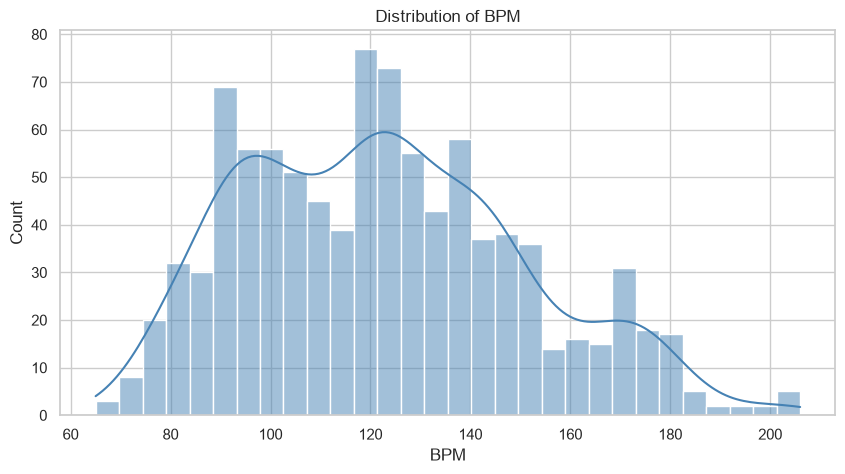

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['bpm'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of BPM')
plt.xlabel('BPM')
plt.ylabel('Count')
plt.show()

In [ ]:
The BPM distribution is roughly bell-shaped and centered around 120–130. Most songs fall between approximately 100 and 150 BPM, with a peak near 120–125.

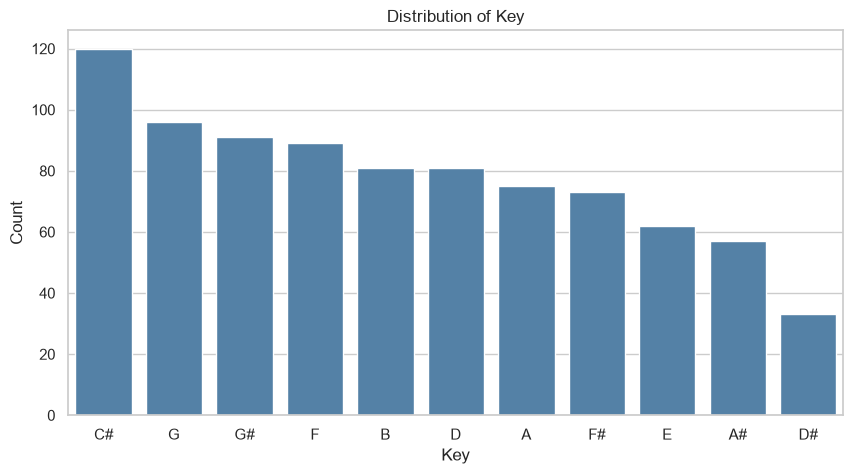

In [8]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='key', order=df['key'].value_counts().index, color='steelblue')
plt.title('Distribution of Key')
plt.xlabel('Key')
plt.ylabel('Count')
plt.show()

In [ ]:
C# is the most common key by a clear margin, followed by G, G#, and F. The distribution is relatively spread out across the 11 keys present in the dataset.

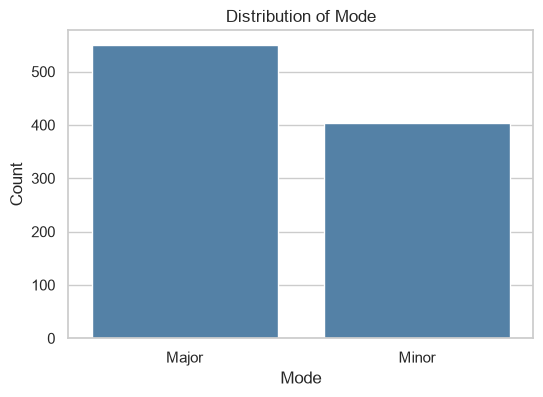

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='mode', color='steelblue')
plt.title('Distribution of Mode')
plt.xlabel('Mode')
plt.ylabel('Count')
plt.show()

In [ ]:
Major mode is more common than Minor mode. Roughly 550 songs are in Major compared to about 400 in Minor.

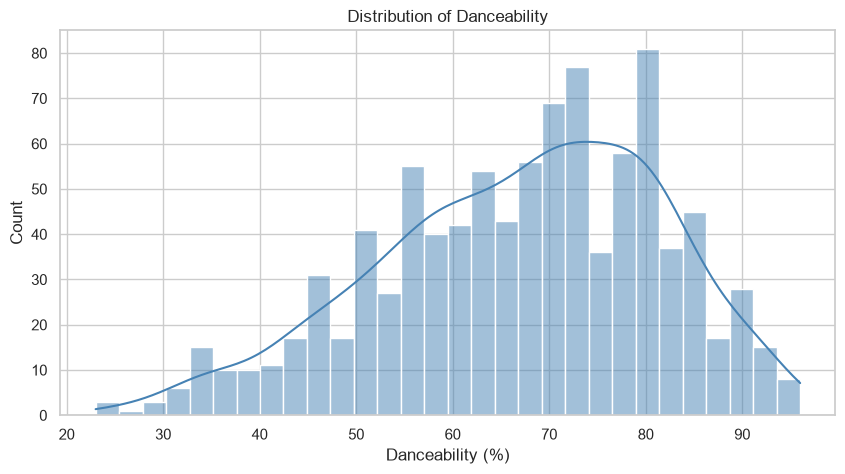

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['danceability_%'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Danceability')
plt.xlabel('Danceability (%)')
plt.ylabel('Count')
plt.show()

In [ ]:
Danceability is moderately high for most songs. The distribution peaks in the 70–80 range, with the majority of tracks falling between 60 and 85.

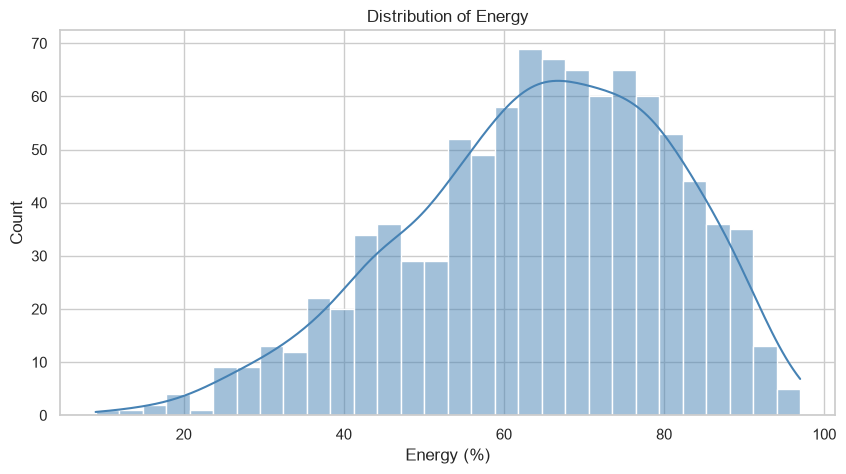

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df['energy_%'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Energy')
plt.xlabel('Energy (%)')
plt.ylabel('Count')
plt.show()

In [ ]:
Energy follows a similar pattern to danceability. Most songs have energy levels between 60 and 85, with a peak around 70.

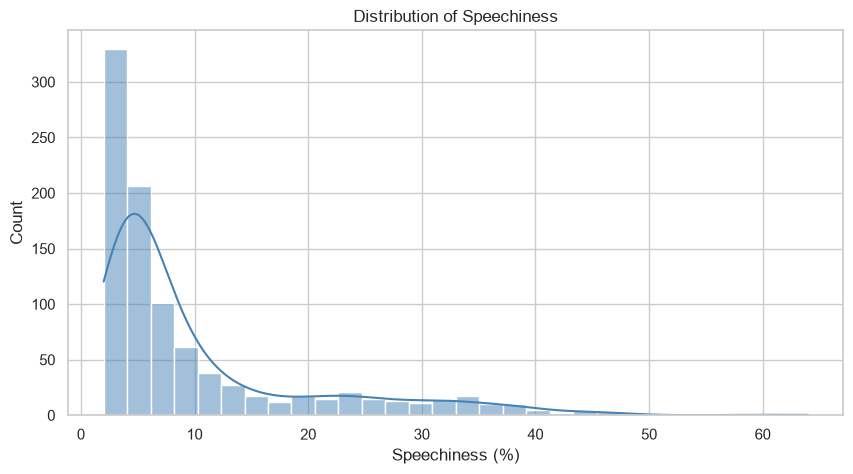

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df['speechiness_%'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Speechiness')
plt.xlabel('Speechiness (%)')
plt.ylabel('Count')
plt.show()

In [ ]:
Speechiness is strongly right-skewed. The large majority of songs have very low speechiness (under 10–15%), with only a small number of tracks having higher spoken-word content.

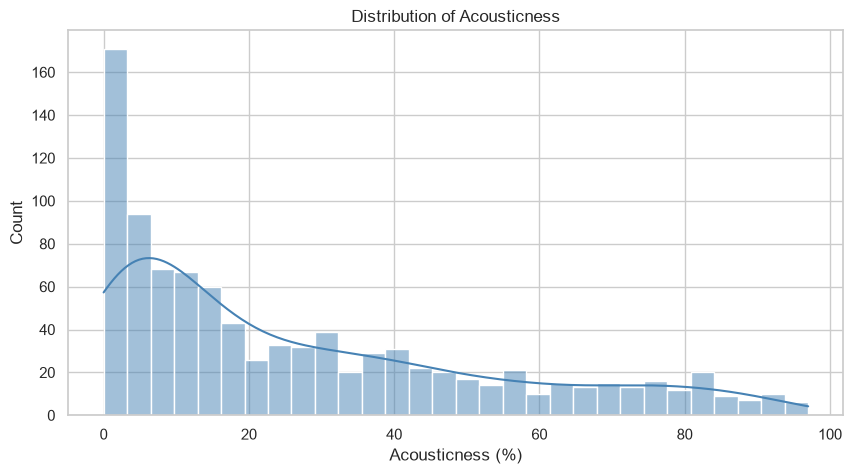

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df['acousticness_%'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Acousticness')
plt.xlabel('Acousticness (%)')
plt.ylabel('Count')
plt.show()

In [ ]:
Acousticness is also right-skewed. Most songs have low acousticness (under 20–30%), indicating that the majority of tracks in this dataset are more produced/electronic rather than acoustic.

BPM = 115 - 135: Peak of the distribution is around 120–130
Key = C#: Clearly the most common key
Mode = Major: More common than Minor
Danceability = 65 – 85: Most songs cluster in the 70s
Energy = 60 – 85: Strong peak between 60–80
Speechiness = 0 – 15: Vast majority of songs are under 15
Acousticness = 0 – 30: Most songs have low acousticness

In [14]:
smash_hits = df[
    (df['bpm'].between(115, 135)) &
    (df['key'] == 'C#') &
    (df['mode'] == 'Major') &
    (df['danceability_%'].between(65, 85)) &
    (df['energy_%'].between(60, 85)) &
    (df['speechiness_%'] <= 15) &
    (df['acousticness_%'] <= 30)
]

smash_hits[['track_name', 'artist(s)_name', 'streams', 'bpm', 'key', 'mode', 
            'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']]

,track_name,artist(s)_name,streams,bpm,key,mode,danceability_%,energy_%,speechiness_%,acousticness_%
106,Cold Heart - PNAU Remix,"Dua Lipa, Elton John, Pnau",1605224506,116,C#,Major,80,80,3,4
168,We Found Love,"Rihanna, Calvin Harris",1235005533,128,C#,Major,73,77,4,3
236,AMERICA HAS A PROBLEM (feat. Kendrick Lamar),"Kendrick Lamar, Beyoncï¿",57089066,126,C#,Major,78,70,4,1
518,Need To Know,Doja Cat,1042568408,130,C#,Major,66,61,7,30
600,I WANNA BE YOUR SLAVE,Mï¿½ï¿½ne,851070493,133,C#,Major,75,61,4,0
778,Dos Mil 16,Bad Bunny,338422004,130,C#,Major,82,67,5,12
845,Belly Dancer,"BYOR, Imanbek",383835984,122,C#,Major,85,80,14,6


In [ ]:
Cold Heart - PNAU Remix (Dua Lipa, Elton John) — over 1.6 billion streams
We Found Love (Rihanna, Calvin Harris) — over 1.2 billion streams
Both were/are extremely popular songs.

In [15]:
chemical = df[df['track_name'].str.contains('Chemical', case=False, na=False)]
chemical[['track_name', 'artist(s)_name', 'streams', 'bpm', 'key', 'mode',
          'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']]

,track_name,artist(s)_name,streams,bpm,key,mode,danceability_%,energy_%,speechiness_%,acousticness_%
102,Chemical,Post Malone,172825906,170,D,Major,50,90,5,0


In [ ]:
Chemical matches on Mode, Speechiness, and Acousticness, but it is significantly faster (170 BPM), less danceable, and higher energy than the “typical” smash hit profile we identified from the data. Despite not matching the average profile perfectly, it was still a successful song with around 173 million streams.